# Analytics Module
The Analytics module provides descriptive statistics on content data, evidence data and model evaluations 

In [1]:
# reloads modules automatically before entering the execution of code
%load_ext autoreload
%autoreload 2

# third parties imports
import numpy as np 
import pandas as pd
# -- add new imports here --
import matplotlib.pyplot as plt
# local imports
from constants import Constant as C
from loaders import load_ratings
from loaders import load_items



# 1 - Content analytics
Explore and perform descriptive statistics on content data

In [2]:
print("Dossier source :", C.CONTENT_PATH)
print("Nom du fichier :", C.ITEMS_FILENAME)
print(C.ITEM_ID_COL)

Dossier source : data\small\content
Nom du fichier : movies.csv
movieId


In [3]:
# -- load the items and display the Dataframe
df_items = load_items()
df_items.head()

,title,genres
movieId,,
1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
2,Jumanji (1995),Adventure|Children|Fantasy
3,Grumpier Old Men (1995),Comedy|Romance
4,Waiting to Exhale (1995),Comedy|Drama|Romance
5,Father of the Bride Part II (1995),Comedy


In [8]:
# -- display relevant informations that can be extracted from the dataset

n_movies = len(df_items)
print(f"Number of movies : {n_movies}")

n_ratings = len(df_ratings)
print(f"Number of ratings : {n_ratings}")

n_unique_users = df_ratings[C.USER_ID_COL].nunique()
print(f"Number of unique users in ratings : {n_unique_users}")

n_unique_movies = df_ratings[C.ITEM_ID_COL].nunique()
print(f"Number of unique movies in ratings : {n_unique_movies}")

n_ratings_most_rated_movie = df_ratings[C.ITEM_ID_COL].value_counts().max()
print(f"Number of ratings for the most rated movie : {n_ratings_most_rated_movie}") 

n_ratings_least_rated_movie = df_ratings[C.ITEM_ID_COL].value_counts().min()
print(f"Number of ratings for the least rated movie : {n_ratings_least_rated_movie}")

possible_ratings = sorted(df_ratings[C.RATING_COL].unique())
print(f"Possible ratings : {possible_ratings}") 

n_not_rated_movies = n_movies - n_unique_movies
print(f"Number of movies that have not been rated : {n_not_rated_movies}")

Number of movies : 9125
Number of ratings : 100004
Number of unique users in ratings : 671
Number of unique movies in ratings : 9066
Number of ratings for the most rated movie : 341
Number of ratings for the least rated movie : 1
Possible ratings : [np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]
Number of movies that have not been rated : 59


# 2 - Evidence analytics
Explore and perform descriptive statistics on evidence data

In [5]:
# -- load the items and display the Dataframe

df_ratings = load_ratings()
df_ratings.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [ ]:
# -- display relevant informations that can be extracted from the dataset



Long-tail property

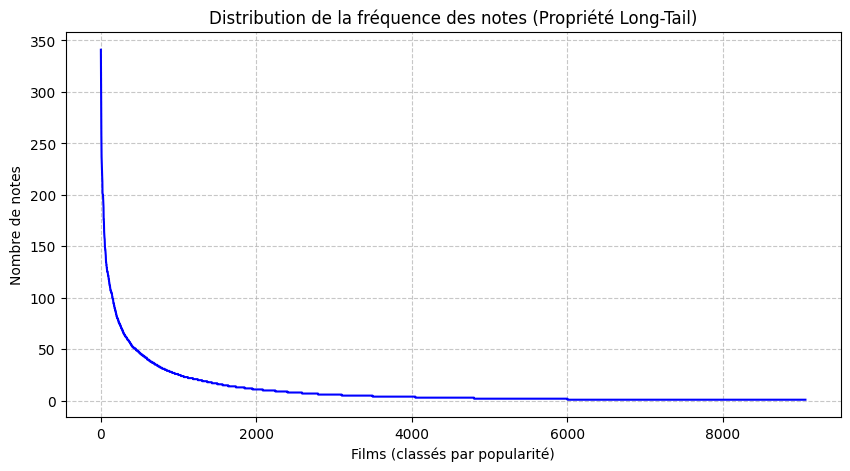

In [6]:
# 1. Compter le nombre de ratings par film
# value_counts() trie automatiquement les résultats du plus grand au plus petit 
movie_counts = df_ratings[C.ITEM_ID_COL].value_counts().values

# 2. Création du graphique
plt.figure(figsize=(10, 5))
plt.plot(movie_counts, color='blue')

# 3. Habillage du graphique
plt.title("Distribution de la fréquence des notes (Propriété Long-Tail)")
plt.xlabel("Films (classés par popularité)")
plt.ylabel("Nombre de notes")
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

In [7]:
# On récupère les dimensions (déjà calculées au point 4)
n_users = df_ratings[C.USER_ID_COL].nunique()
n_items = df_ratings[C.ITEM_ID_COL].nunique()
total_ratings = len(df_ratings)

# Calcul du nombre total de cellules possibles dans la matrice
total_possible_ratings = n_users * n_items

# Formule de la sparsité
sparsity = (1 - (total_ratings / total_possible_ratings)) * 100
print(f"Matrix Sparsity: {sparsity:.4f}%")

Matrix Sparsity: 98.3561%
